# Análisis exploratorio de datos multivariado

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from IPython.display import HTML

In [2]:
df = pd.read_csv(r'C:\Users\elias\OneDrive\Desktop\dataviz_py\eda-jbook\docs\NGACOL.csv')

## Análisis multivariado

### Matriz de correlación (Spearman)

Se usa el coeficiente de Spearman ya que como se concluyó y probó anteriormente, ninguna de las variables sigue una distribución normal.

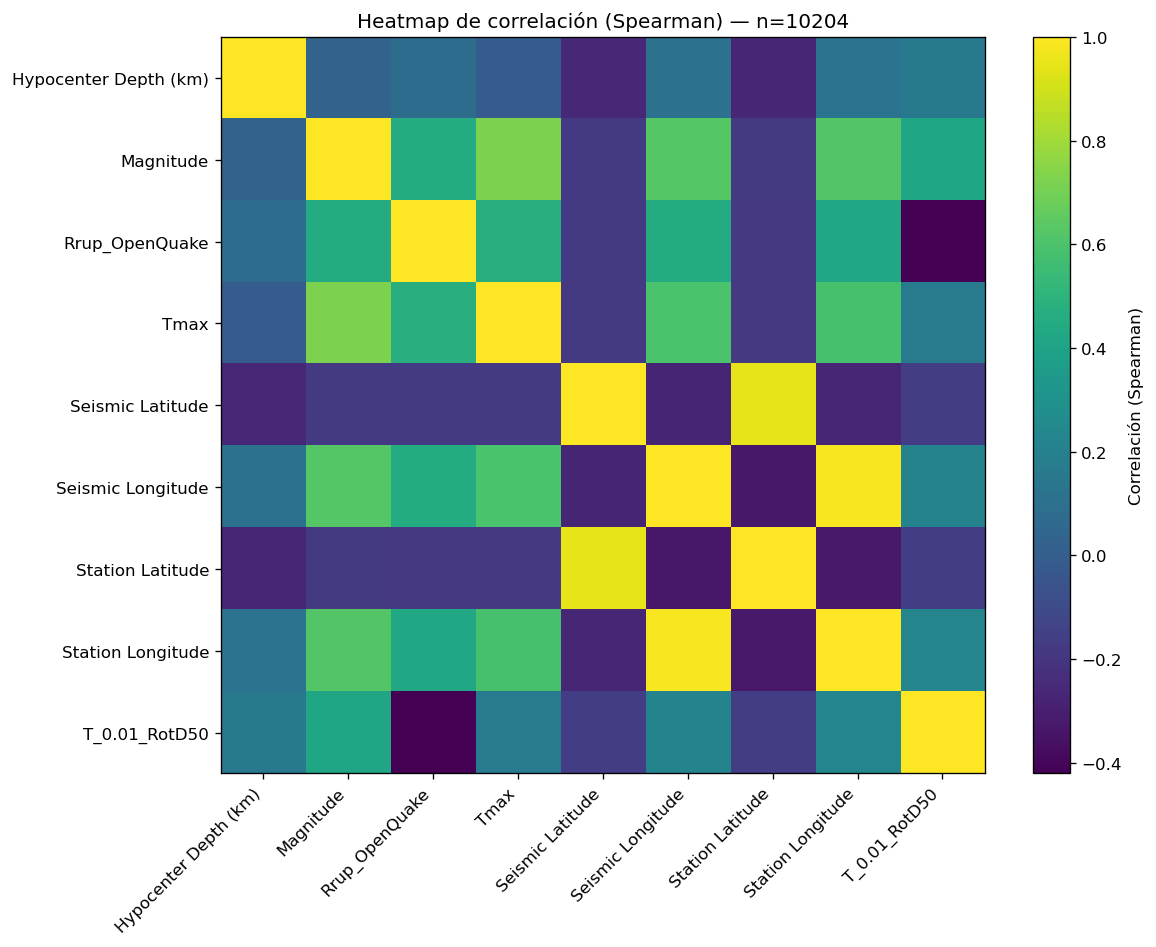

In [3]:
num_cols = [
    "Hypocenter Depth (km)", "Magnitude", "Rrup_OpenQuake", "Tmax",
    "Seismic Latitude", "Seismic Longitude",
    "Station Latitude", "Station Longitude",
    "T_0.01_RotD50"
]

d = df[num_cols].copy()
for c in num_cols:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna()

corr = d.corr(method="spearman")

plt.figure(figsize=(10, 8), dpi=120)
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label="Correlación (Spearman)")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.title(f"Heatmap de correlación (Spearman) — n={len(d)}")
plt.tight_layout()
plt.show()

In [4]:
corr

,Hypocenter Depth (km),Magnitude,Rrup_OpenQuake,Tmax,Seismic Latitude,Seismic Longitude,Station Latitude,Station Longitude,T_0.01_RotD50
Hypocenter Depth (km),1.000000,0.033411,0.082140,-0.005012,-0.258708,0.114885,-0.267013,0.122272,0.156363
Magnitude,0.033411,1.000000,0.450724,0.722550,-0.178591,0.625156,-0.178466,0.619650,0.412468
Rrup_OpenQuake,0.082140,0.450724,1.000000,0.467714,-0.179214,0.451589,-0.182411,0.423086,-0.420402
Tmax,-0.005012,0.722550,0.467714,1.000000,-0.180257,0.596377,-0.184205,0.584582,0.170410
Seismic Latitude,-0.258708,-0.178591,-0.179214,-0.180257,1.000000,-0.273195,0.947388,-0.265437,-0.161578
Seismic Longitude,0.114885,0.625156,0.451589,0.596377,-0.273195,1.000000,-0.329726,0.985395,0.217293
Station Latitude,-0.267013,-0.178466,-0.182411,-0.184205,0.947388,-0.329726,1.000000,-0.324354,-0.162873
Station Longitude,0.122272,0.619650,0.423086,0.584582,-0.265437,0.985395,-0.324354,1.000000,0.224352
T_0.01_RotD50,0.156363,0.412468,-0.420402,0.170410,-0.161578,0.217293,-0.162873,0.224352,1.000000


Se puede evidenciar como la magnitud y la distancia de ruptura están medianamente ccorrelacionadas con la variable respuesta, mientras que el resto de variables están muy bajas en terminos de correlación.
Por otra parte, las coordenadas de estaciones y eventos sismicos tienen una correlación bastante alta

### Matriz multivariada de distribuciones usando ln(Rrup_Openquake) y ln(T_0.01_RotD50)

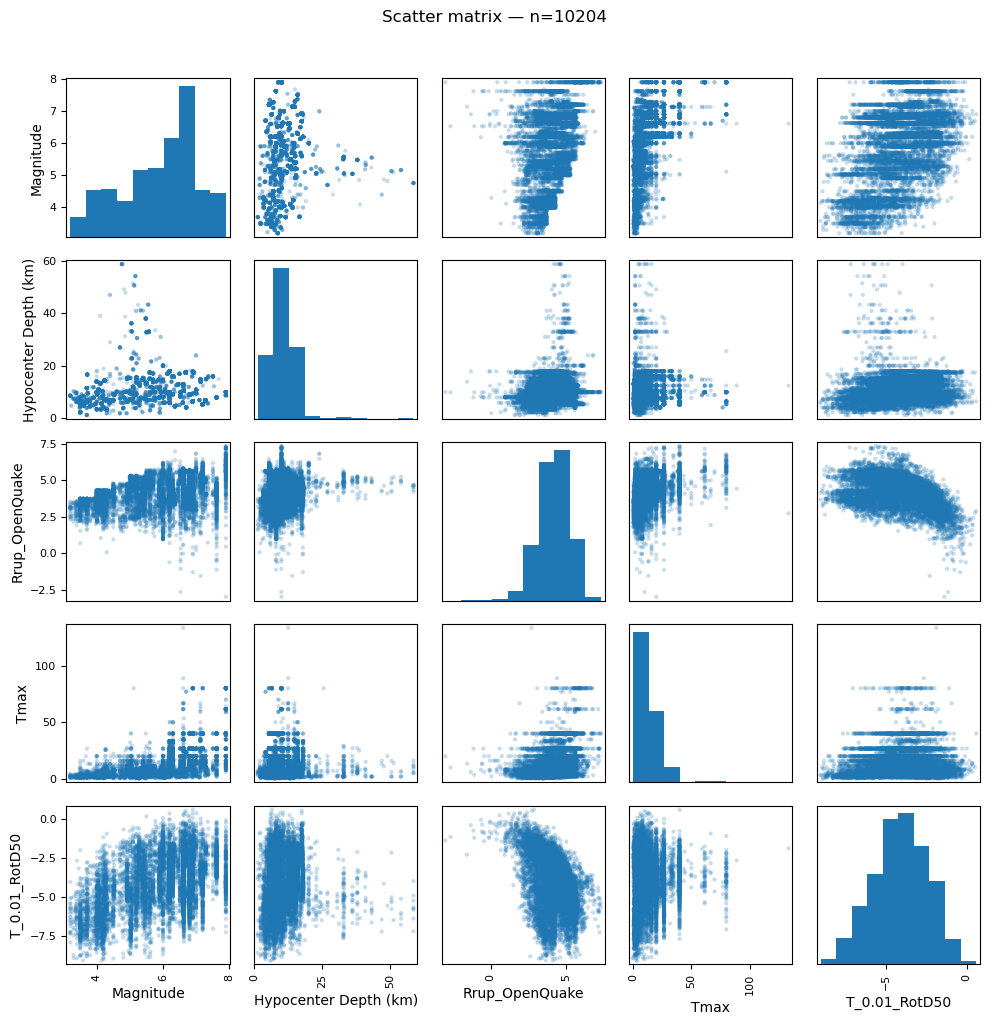

In [5]:
from pandas.plotting import scatter_matrix

cols = ["Magnitude", "Hypocenter Depth (km)", "Rrup_OpenQuake", "Tmax", "T_0.01_RotD50"]

d = df[cols].copy()
for c in cols:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna()

axes = scatter_matrix(d, figsize=(10, 10), diagonal="hist", alpha=0.25)
plt.suptitle(f"Scatter matrix — n={len(d)}", y=1.02)
plt.tight_layout()
plt.show()

### Scatterplot 3D de las variables "Rrup_OpenQuake", "Magnitude" y "T_0.01_RotD50" usando diferenciación de color por Hypocenter Depth (km)

In [6]:
import plotly.express as px

cols = ["Rrup_OpenQuake", "Magnitude", "T_0.01_RotD50", "Hypocenter Depth (km)"]
d = df[cols].copy()
for c in cols:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna()

fig = px.scatter_3d(
    d,
    x="Rrup_OpenQuake",
    y="Magnitude",
    z="T_0.01_RotD50",
    color="Hypocenter Depth (km)",
    title=f"3D: T_0.01_RotD50 vs (Rrup, Magnitude) — color=Depth — n={len(d)}"
)
fig.update_traces(marker=dict(size=2, opacity=0.6))
fig.update_layout(height=650)
fig.show()

Se puede evidenciar que en particular, aquellos eventos sísmicos corticales mas profundos están entre magnitudes 4 y 6 con un ln(T_0.01_RotD50) entre -8 y -4 lo que indica que son sismos que no tuvieron una gran aceleración.

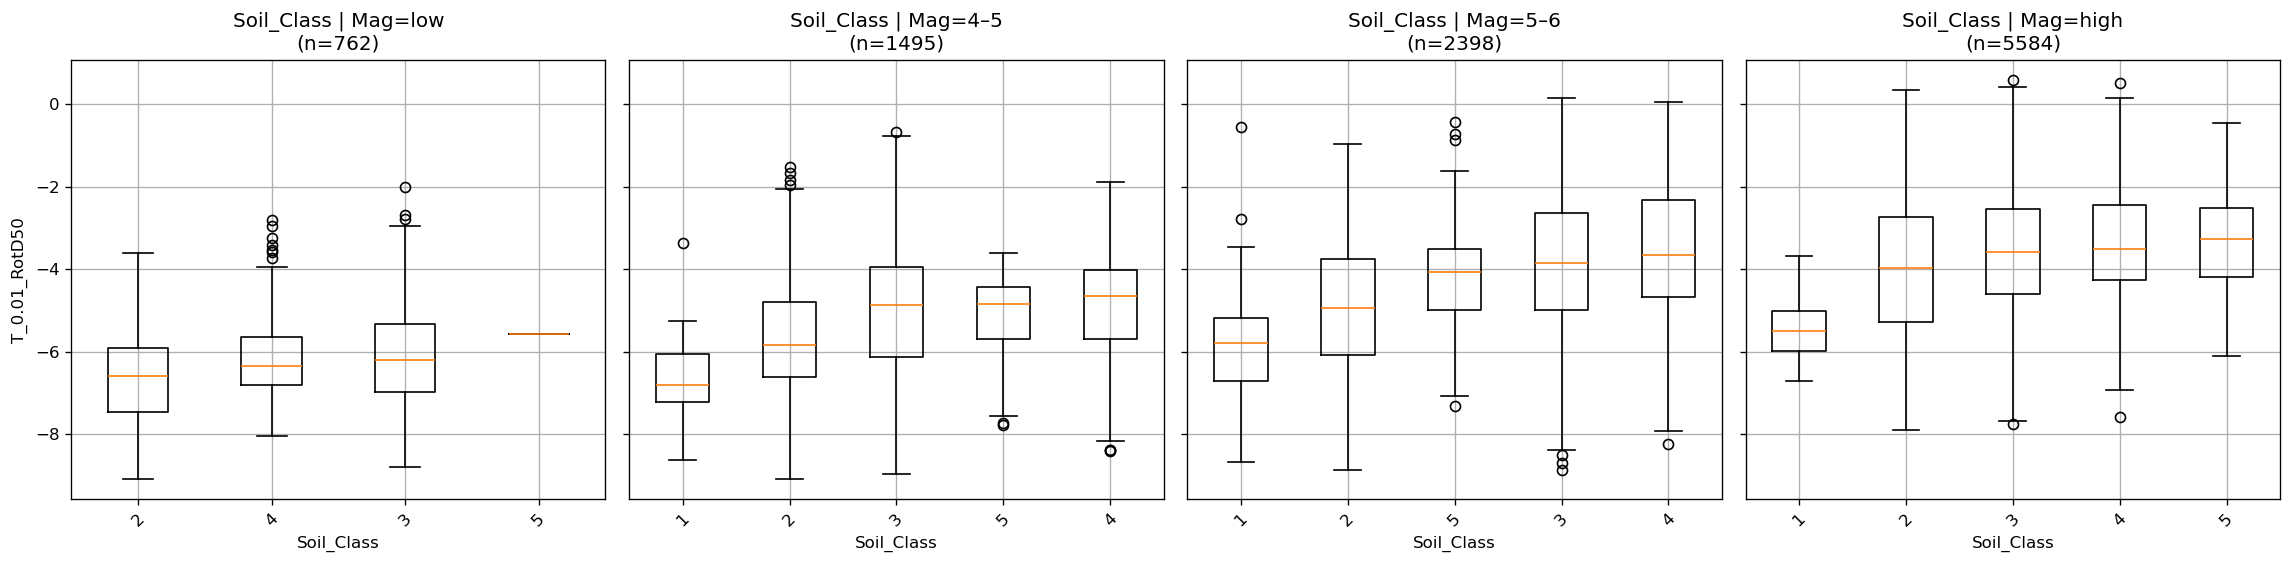

In [7]:
cols = ["Soil_Class", "Magnitude", "T_0.01_RotD50"]
d = df[cols].copy()
d["Soil_Class"] = d["Soil_Class"].astype("string").fillna("NA")
d["Magnitude"] = pd.to_numeric(d["Magnitude"], errors="coerce")
d["T_0.01_RotD50"] = pd.to_numeric(d["T_0.01_RotD50"], errors="coerce")
d = d.dropna(subset=["Magnitude", "T_0.01_RotD50"])

# bins simples de magnitud
bins = [d["Magnitude"].min(), 4, 5, 6, d["Magnitude"].max()]
labels = ["low", "4–5", "5–6", "high"]
d["Mag_group"] = pd.cut(d["Magnitude"], bins=bins, include_lowest=True, labels=labels)

groups = [g for g in labels if g in d["Mag_group"].astype("string").unique()]

fig, axes = plt.subplots(1, len(groups), figsize=(4.8*len(groups), 4.8), dpi=120, sharey=True)
if len(groups) == 1:
    axes = [axes]

for ax, g in zip(axes, groups):
    dg = d[d["Mag_group"] == g]

    # ordenar suelos por mediana
    order = dg.groupby("Soil_Class")["T_0.01_RotD50"].median().sort_values().index.tolist()
    data = [dg.loc[dg["Soil_Class"] == k, "T_0.01_RotD50"].values for k in order]

    ax.boxplot(data, tick_labels=[str(k) for k in order], showfliers=True)
    ax.set_title(f"Soil_Class | Mag={g}\n(n={len(dg)})")
    ax.set_xlabel("Soil_Class")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True)

axes[0].set_ylabel("T_0.01_RotD50")
plt.tight_layout()
plt.show()

En estos boxplots se ve un patrón consistente. Al aumentar la magnitud, la mediana de T_0.01_RotD50 sube en todas las clases de suelo, y además la separación entre suelos se vuelve más clara en los rangos 5–6. En particular, para magnitudes medias–altas, las clases 2–5 tienden a presentar medianas más altas que la clase 1 (y en general mayor dispersión), lo cual sugiere un efecto de sitio sobre la respuesta que persiste incluso controlando por magnitud. En el grupo la comparación es menos robusta porque hay menos datos y algunas clases aparecen con muestras muy pequeñas.

In [8]:

cols = ["Seismic Latitude", "Seismic Longitude", "Magnitude", "T_0.01_RotD50"]
d = df[cols].copy()
for c in ["Seismic Latitude", "Seismic Longitude", "Magnitude", "T_0.01_RotD50"]:
    if c == "T_0.01_RotD50":
        d[c] = np.exp(pd.to_numeric(d[c], errors="coerce"))
    else:
        d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna()

fig = px.scatter_geo(
    d,
    lat="Seismic Latitude",
    lon="Seismic Longitude",
    color="Magnitude",
    size="T_0.01_RotD50",
    projection="natural earth",
    title=f"Eventos: color=Magnitud, tamaño=T_0.01_RotD50 — n={len(d)}"
)
fig.update_traces(marker=dict(opacity=0.6))
fig.update_layout(height=600)
fig
HTML(pio.to_html(fig, include_plotlyjs="cdn", full_html=False))